In [1]:
%run ../bootstrap.py

[Bootstrap] cwd=/home/ikk/renal-calculi-classificaction | seed=57


In [2]:
from src.data.dataset_builder import DatasetBuilder, assign_task_labels

In [3]:

import pandas as pd
import numpy as np
from itertools import product
from pathlib import Path

from src.features.lbp import LocalBinaryPattern
from src.features.hsv import HSV_extractor
from src.features.feature_extractor import FeatureExtractor 
from src.pipelines.xgboost_pipeline import XGBoostExperiment
from src.utils.constants import Case
import json

def search_best_lbp_params(
    df: pd.DataFrame,
    output_dir: Path,
    best_params_path: str,
    num_points_values: list[int] = (8, 16),
    radius_values: list[int] = (1, 2),
    class_names: list = None,
) -> pd.DataFrame:
    """
    Ejecuta XGBoost en K-fold para cada combinación (P, R) y devuelve un DataFrame con resultados.
    """

    results = []
    
    # Producto cartesiano: todas las combinaciones (P, R)
    combinations = list(product(num_points_values, radius_values))
    
    for i, (P, R) in enumerate(combinations, start=1):
        print(f" Configuración: {i}/{len(combinations)}: P={P}, R={R} ")
        
        
        lbp = LocalBinaryPattern(numPoints=P, radius=R)
        hsv = HSV_extractor(n_bins=P+2)
        extractor = FeatureExtractor(hsv, lbp)
        model = XGBoostExperiment(df, extractor, Case.IMAGE)
        exp_name = f"lbp_search_P{P}_R{R}"
        config = {
            "name": exp_name,
            "output_dir": str(output_dir / exp_name),
            "best_params": best_params_path,  
            "class_names": class_names,
        }
        best_params= dict()
        with open(best_params_path) as f:
            best_params= json.load(f)

        
        # Ejecutar K-fold
        result = model.evaluate_cv(config,best_params)
        
        # Recopilar métricas clave
        s = result["summary"]
        results.append({
            "num_points": P,
            "radius": R,
            "n_bins": P + 2,  
            "f1_weighted_mean": s["f1_weighted_mean"],
            "f1_weighted_std": s["f1_weighted_std"],
            "accuracy_mean": s["accuracy_mean"],
            "accuracy_std": s["accuracy_std"],
            "auc_weighted_mean": s.get("auc_weighted_mean"),
            "auc_weighted_std": s.get("auc_weighted_std"),
        })
        
        print(f" F1: {s['f1_weighted_mean']:.4f} ± {s['f1_weighted_std']:.4f}\n")
    
    # Guardar los resultados
    results_df = pd.DataFrame(results)
    results_df.to_csv(output_dir / "lbp_search_summary.csv", index=False)
    
    # Mostrar resultados ordenados de mejor a peor
    print("\nRESULTADOS ORDENADOS POR F1")
    sorted_df = results_df.sort_values("f1_weighted_mean", ascending=False)
    print(sorted_df.to_string(index=False))
    
    return results_df

In [4]:
builder = DatasetBuilder(root_path= DATASET_PATH_XGBOOST)
task_config= TASKS["binario"]
df = builder.build(classes=task_config["classes"])

 Configuración: 1/4: P=8, R=1 
  Features shape: (397, 40)
  Distribución: {0: 192, 1: 205}

EVALUACIÓN CV: lbp_search_P8_R1 (5 folds)
  use_augmentation = False

RESULTADOS CV 5 -fold (media ± std entre folds):
  accuracy: 0.8296 ± 0.0403
  auc_weighted: 0.8979 ± 0.0283
  f1_weighted: 0.8294 ± 0.0401
  precision_weighted: 0.8300 ± 0.0405
  recall_weighted: 0.8296 ± 0.0403


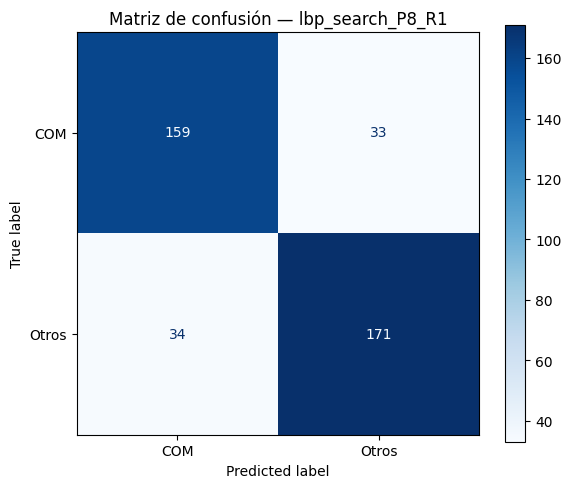

 F1: 0.8294 ± 0.0401

 Configuración: 2/4: P=8, R=2 
  Features shape: (397, 40)
  Distribución: {0: 192, 1: 205}

EVALUACIÓN CV: lbp_search_P8_R2 (5 folds)
  use_augmentation = False

RESULTADOS CV 5 -fold (media ± std entre folds):
  accuracy: 0.8436 ± 0.0398
  auc_weighted: 0.9007 ± 0.0273
  f1_weighted: 0.8437 ± 0.0397
  precision_weighted: 0.8449 ± 0.0392
  recall_weighted: 0.8436 ± 0.0398


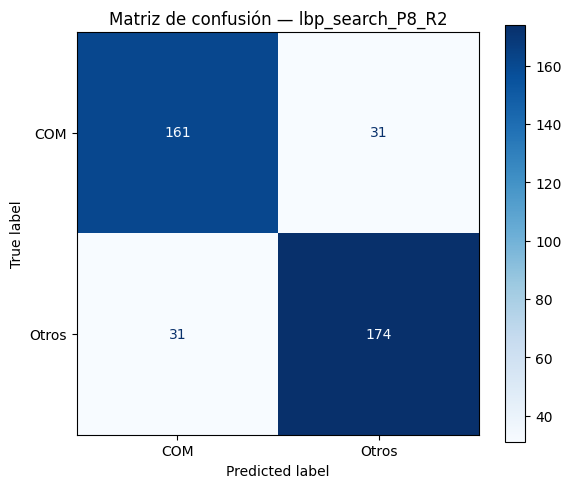

 F1: 0.8437 ± 0.0397

 Configuración: 3/4: P=16, R=1 
  Features shape: (397, 72)
  Distribución: {0: 192, 1: 205}

EVALUACIÓN CV: lbp_search_P16_R1 (5 folds)
  use_augmentation = False

RESULTADOS CV 5 -fold (media ± std entre folds):
  accuracy: 0.8182 ± 0.0392
  auc_weighted: 0.8982 ± 0.0247
  f1_weighted: 0.8180 ± 0.0394
  precision_weighted: 0.8186 ± 0.0399
  recall_weighted: 0.8182 ± 0.0392


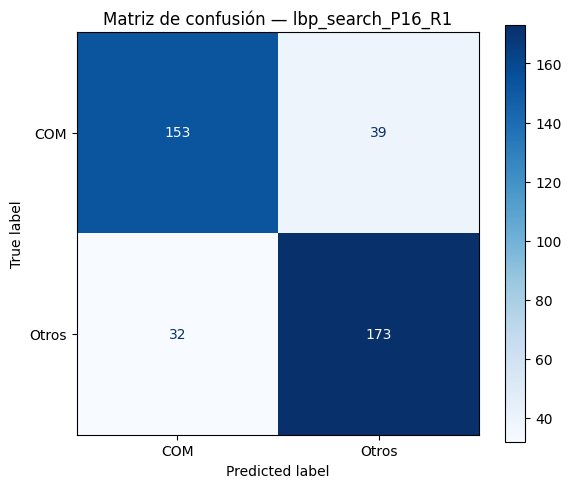

 F1: 0.8180 ± 0.0394

 Configuración: 4/4: P=16, R=2 
  Features shape: (397, 72)
  Distribución: {0: 192, 1: 205}

EVALUACIÓN CV: lbp_search_P16_R2 (5 folds)
  use_augmentation = False

RESULTADOS CV 5 -fold (media ± std entre folds):
  accuracy: 0.8203 ± 0.0456
  auc_weighted: 0.8957 ± 0.0314
  f1_weighted: 0.8200 ± 0.0458
  precision_weighted: 0.8203 ± 0.0461
  recall_weighted: 0.8203 ± 0.0456


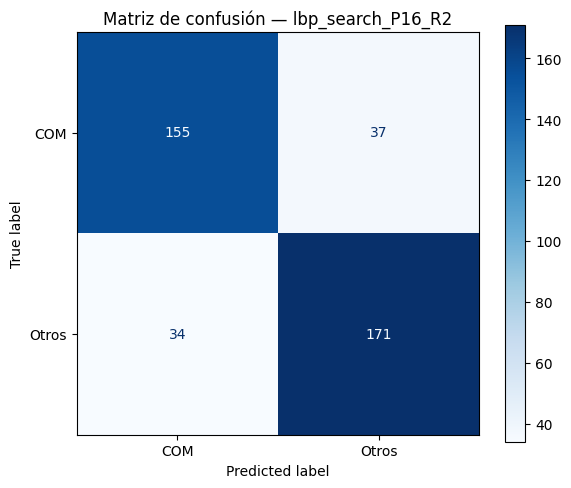

 F1: 0.8200 ± 0.0458


RESULTADOS ORDENADOS POR F1
 num_points  radius  n_bins  f1_weighted_mean  f1_weighted_std  accuracy_mean  accuracy_std  auc_weighted_mean  auc_weighted_std
          8       2      10          0.843675         0.039722       0.843627      0.039777           0.900679          0.027308
          8       1      10          0.829360         0.040113       0.829594      0.040322           0.897889          0.028341
         16       2      18          0.819963         0.045757       0.820301      0.045559           0.895682          0.031374
         16       1      18          0.817964         0.039414       0.818183      0.039160           0.898243          0.024681


In [6]:
results_image = search_best_lbp_params(
    df=df,
    output_dir=Path("experiments/lbp_search"),
    best_params_path="experiments/xgboost/xgboost_images/xgboost_binario/best_params.json",
    class_names=task_config["class_names"]
)

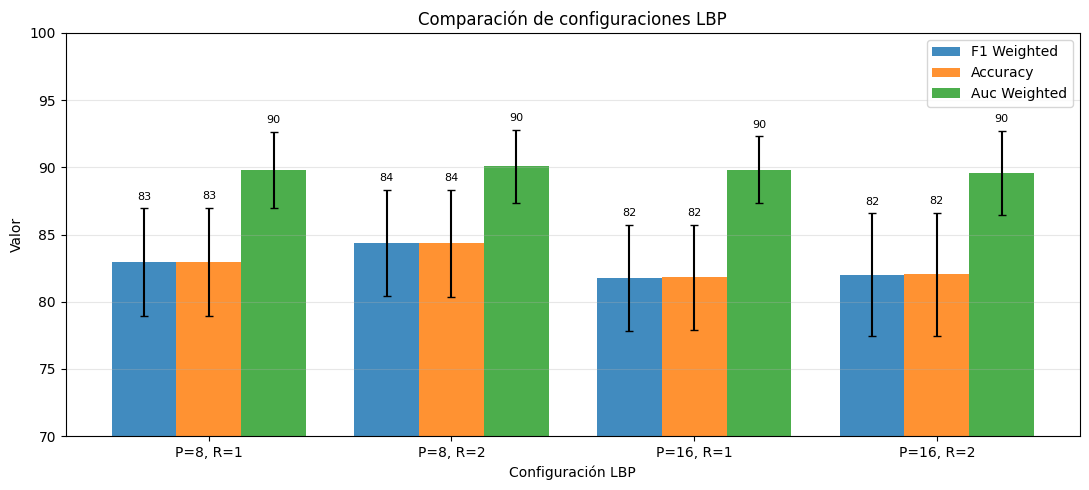

In [8]:

from src.utils.visualization import plot_lbp_multi_metric
fig_image = plot_lbp_multi_metric(df= results_image, labels = [f"P={p}, R={r}" for p, r in zip(results_image["num_points"], results_image["radius"])], xlabel="Configuración LBP", ylabel= "Valor", title= "Comparación de configuraciones LBP" )
fig_image.show()
fig_image.savefig("experiments/plots/comparación de parametros P y R", dpi= 100)